# CoreLearn — PyPI Demo Notebook

This notebook installs **CoreLearn directly from PyPI** and demonstrates all features.

| Section | Dataset | Task |
|---------|---------|------|
| 1 | Palmer Penguins (CSV) | `KNNClassifier` — k sweep, distance metrics, confusion matrix |
| 2 | California Housing (sklearn) | `LinearRegression` — Normal Equation vs Gradient Descent |

> **No local path setup needed.** The package is installed from PyPI.

In [10]:
# Install CoreLearn from PyPI
# Run this cell once — skip if already installed
%pip install coreLearn scikit-learn pandas matplotlib --quiet


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [12]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from coreLearn import (
    KNNClassifier,
    LinearRegression,
    Evaluator,
    accuracy, mae, mse, rmse,
    precision, recall, f1_score,
)
import coreLearn

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})
print(f'coreLearn v{coreLearn.__version__} loaded')


coreLearn v0.1.0 loaded


---
## Section 1 — KNNClassifier : Palmer Penguins

**Goal:** Classify 3 penguin species (`Adelie`, `Gentoo`, `Chinstrap`) from 4 physical measurements.

**Concepts demonstrated:** Factory Pattern · KD-Tree Recursion · ProcessPoolExecutor Concurrency

In [13]:
df = pd.read_csv('penguin.csv')
print(f'Shape    : {df.shape}')
print(f'Species  : {df["species"].value_counts().to_dict()}')
df.head(3)


Shape    : (344, 8)
Species  : {'Adelie': 152, 'Gentoo': 124, 'Chinstrap': 68}


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007


In [14]:
# Preprocessing
df_p = df.dropna().copy()
df_p = pd.get_dummies(df_p, columns=['island', 'sex'], drop_first=True)
df_p.drop(columns=['year'], inplace=True)

features = [c for c in df_p.columns if c != 'species']
X_pg = df_p[features].values.astype(float)
y_pg = df_p['species'].values.tolist()
classes = sorted(set(y_pg))

X_tr, X_te, y_tr, y_te = train_test_split(
    X_pg, y_pg, test_size=0.25, random_state=42, stratify=y_pg
)
sc = StandardScaler()
X_tr_sc = sc.fit_transform(X_tr)
X_te_sc  = sc.transform(X_te)

print(f'Train: {len(X_tr)}   Test: {len(X_te)}   Features: {len(features)}')

Train: 249   Test: 84   Features: 7


In [15]:
# ── Factory Pattern: distance metric selected by name string ──
knn = KNNClassifier(k=5, distance='euclidean', n_jobs=1)
knn.fit(X_tr_sc.tolist(), y_tr)
preds = knn.predict(X_te_sc.tolist())

metrics = Evaluator.evaluate_classification(y_te, preds)
print('KNN  k=5 | euclidean | Penguins')
print('─' * 34)
for name, val in metrics.items():
    print(f'  {name:<12} {val:.4f}')

KNN  k=5 | euclidean | Penguins
──────────────────────────────────
  accuracy     0.9881
  precision    0.9815
  recall       0.9910
  f1           0.9859


In [16]:
# k sweep — euclidean vs manhattan
k_vals = [1, 3, 5, 7, 11, 15]
results = {d: {'acc': [], 'f1': []} for d in ['euclidean', 'manhattan']}

for dist in ['euclidean', 'manhattan']:
    for k in k_vals:
        m = KNNClassifier(k=k, distance=dist)
        m.fit(X_tr_sc.tolist(), y_tr)
        p = m.predict(X_te_sc.tolist())
        r = Evaluator.evaluate_classification(y_te, p)
        results[dist]['acc'].append(r['accuracy'])
        results[dist]['f1'].append(r['f1'])

print(f"{'k':<5} {'Eucl Acc':>10} {'Eucl F1':>10} {'Manh Acc':>10} {'Manh F1':>10}")
print('─' * 50)
for i, k in enumerate(k_vals):
    print(f"{k:<5} {results['euclidean']['acc'][i]:>10.4f} "
          f"{results['euclidean']['f1'][i]:>10.4f} "
          f"{results['manhattan']['acc'][i]:>10.4f} "
          f"{results['manhattan']['f1'][i]:>10.4f}")

k       Eucl Acc    Eucl F1   Manh Acc    Manh F1
──────────────────────────────────────────────────
1         0.9881     0.9859     0.9881     0.9859
3         0.9881     0.9859     0.9881     0.9859
5         0.9881     0.9859     0.9881     0.9859
7         1.0000     1.0000     0.9881     0.9859
11        1.0000     1.0000     1.0000     1.0000
15        1.0000     1.0000     1.0000     1.0000


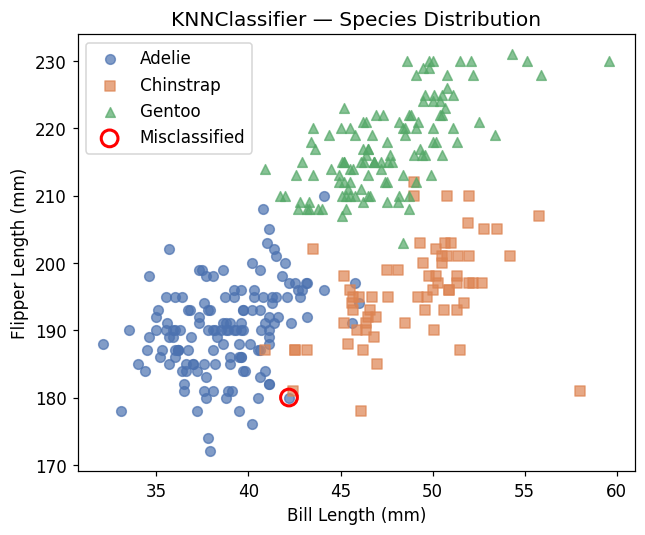

In [17]:
fig, ax = plt.subplots(figsize=(6, 5))

num_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
bl_i = num_cols.index('bill_length_mm')
fl_i = num_cols.index('flipper_length_mm')
colors  = {'Adelie': '#4C72B0', 'Chinstrap': '#DD8452', 'Gentoo': '#55A868'}
markers = {'Adelie': 'o', 'Chinstrap': 's', 'Gentoo': '^'}

for sp in classes:
    mask = np.array(y_pg) == sp
    ax.scatter(X_pg[mask, bl_i], X_pg[mask, fl_i],
               s=40, alpha=0.7, color=colors[sp], marker=markers[sp], label=sp)

wrong = [i for i, (t, p) in enumerate(zip(y_te, preds)) if t != p]
if wrong:
    ax.scatter(X_te[wrong, bl_i], X_te[wrong, fl_i],
               s=120, facecolors='none', edgecolors='red', lw=2, label='Misclassified')

ax.set(xlabel='Bill Length (mm)', ylabel='Flipper Length (mm)',
       title='KNNClassifier — Species Distribution')
ax.legend()
plt.tight_layout()
plt.show()


---
## Section 2 — LinearRegression : California Housing

**Goal:** Predict house prices from 8 features.

**Concepts demonstrated:** Strategy Pattern · Template Method · SOLID (Dependency Inversion)

In [18]:
df_h = pd.read_csv('housing.csv').dropna()
df_h = pd.get_dummies(df_h, columns=['ocean_proximity'], drop_first=True)

feature_names = [c for c in df_h.columns if c != 'median_house_value']
X_h = df_h[feature_names].values.astype(float)
y_h = (df_h['median_house_value'].values / 100_000).astype(float)

X_tr_h, X_te_h, y_tr_h, y_te_h = train_test_split(X_h, y_h, test_size=0.2, random_state=42)

sc_X = StandardScaler(); sc_y = StandardScaler()
X_tr_sc_h = sc_X.fit_transform(X_tr_h)
X_te_sc_h  = sc_X.transform(X_te_h)
y_tr_sc_h  = sc_y.fit_transform(y_tr_h.reshape(-1, 1)).ravel()

print(f'Samples : {X_h.shape[0]:,}   Features: {X_h.shape[1]}')
print(f'Train   : {len(X_tr_h):,}   Test: {len(X_te_h):,}')


Samples : 20,433   Features: 12
Train   : 16,346   Test: 4,087


In [19]:
# ── Strategy Pattern: swap optimiser by passing a string ──

# Strategy 1 — Normal Equation (closed-form, fast)
t0 = time.perf_counter()
lr_ne = LinearRegression(strategy='normal')
lr_ne.fit(X_tr_sc_h.tolist(), y_tr_sc_h.tolist())
t_ne = time.perf_counter() - t0

preds_ne = sc_y.inverse_transform(
    np.array(lr_ne.predict(X_te_sc_h.tolist())).reshape(-1, 1)).ravel()
ne_metrics = Evaluator.evaluate_regression(y_te_h.tolist(), preds_ne.tolist())
ne_r2 = 1 - np.sum((y_te_h - preds_ne)**2) / np.sum((y_te_h - y_te_h.mean())**2)

print(f'Normal Equation  ({t_ne*1000:.1f} ms)')
print(f'  MAE={ne_metrics["mae"]:.4f}  RMSE={ne_metrics["rmse"]:.4f}  R²={ne_r2:.4f}')
print(f'  intercept = {lr_ne.intercept_:.4f}')
print(f'  coef      = {np.round(lr_ne.coef_, 3)}')

Normal Equation  (19.2 ms)
  MAE=0.5041  RMSE=0.6930  R²=0.6488
  intercept = -0.0000
  coef      = [-0.473 -0.476  0.118 -0.118  0.374 -0.357  0.142  0.648 -0.158  0.025
 -0.017  0.009]


In [20]:
# Strategy 2 — Gradient Descent (iterative)
t0 = time.perf_counter()
lr_gd = LinearRegression(strategy='gradient_descent', learning_rate=0.1, epochs=2000)
lr_gd.fit(X_tr_sc_h.tolist(), y_tr_sc_h.tolist())
t_gd = time.perf_counter() - t0

preds_gd = sc_y.inverse_transform(
    np.array(lr_gd.predict(X_te_sc_h.tolist())).reshape(-1, 1)).ravel()
gd_metrics = Evaluator.evaluate_regression(y_te_h.tolist(), preds_gd.tolist())
gd_r2 = 1 - np.sum((y_te_h - preds_gd)**2) / np.sum((y_te_h - y_te_h.mean())**2)

print(f'Gradient Descent ({t_gd*1000:.1f} ms, 2000 epochs)')
print(f'  MAE={gd_metrics["mae"]:.4f}  RMSE={gd_metrics["rmse"]:.4f}  R²={gd_r2:.4f}')

Gradient Descent (153.5 ms, 2000 epochs)
  MAE=0.5041  RMSE=0.6929  R²=0.6489


In [21]:
# ── Template Method: fit_predict() inherited from BaseModel ──
preds_fp = LinearRegression(strategy='normal').fit_predict(
    X_tr_sc_h.tolist(), y_tr_sc_h.tolist(), X_te_sc_h.tolist()
)
print('fit_predict() — same result as fit() + predict() separately')

# Comparison table
summary = pd.DataFrame({
    'Strategy':  ['Normal Equation', 'Gradient Descent'],
    'MAE':        [ne_metrics['mae'],  gd_metrics['mae']],
    'RMSE':       [ne_metrics['rmse'], gd_metrics['rmse']],
    'R²':         [ne_r2,              gd_r2],
    'Time (ms)':  [round(t_ne*1000,1), round(t_gd*1000,1)],
}).set_index('Strategy')
display(summary.round(4))

fit_predict() — same result as fit() + predict() separately


,MAE,RMSE,R²,Time (ms)
Strategy,,,,
Normal Equation,0.5041,0.6930,0.6488,19.2
Gradient Descent,0.5041,0.6929,0.6489,153.5


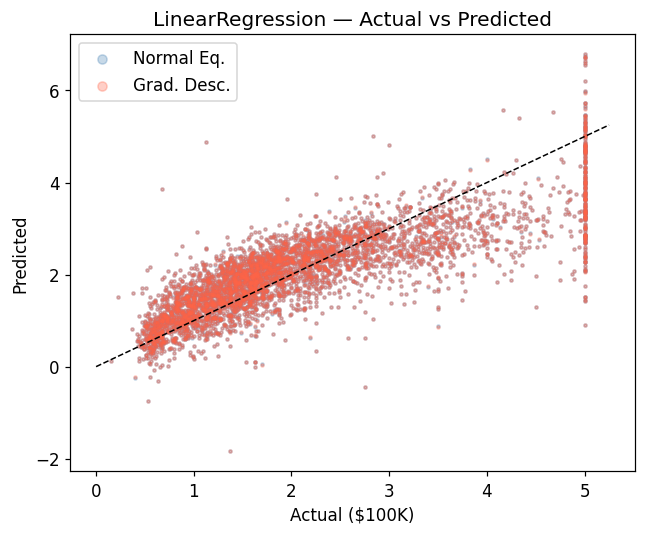

In [22]:
fig, ax = plt.subplots(figsize=(6, 5))

ax.scatter(y_te_h, preds_ne, s=4, alpha=0.3, color='steelblue', label='Normal Eq.')
ax.scatter(y_te_h, preds_gd, s=4, alpha=0.3, color='tomato',    label='Grad. Desc.')
lims = [0, y_te_h.max() * 1.05]
ax.plot(lims, lims, 'k--', lw=1)
ax.set(xlabel='Actual ($100K)', ylabel='Predicted',
       title='LinearRegression — Actual vs Predicted')
ax.legend(markerscale=3)
plt.tight_layout()
plt.show()


### Benchmark — sklearn LinearRegression

In [23]:
from sklearn.linear_model import LinearRegression as SklearnLR

t0 = time.perf_counter()
sk_lr = SklearnLR()
sk_lr.fit(X_tr_sc_h, y_tr_sc_h)
t_sk = time.perf_counter() - t0

preds_sk = sc_y.inverse_transform(
    sk_lr.predict(X_te_sc_h).reshape(-1, 1)).ravel()
sk_mae  = mae(y_te_h.tolist(), preds_sk.tolist())
sk_rmse = rmse(y_te_h.tolist(), preds_sk.tolist())
sk_r2   = 1 - np.sum((y_te_h - preds_sk)**2) / np.sum((y_te_h - y_te_h.mean())**2)

print(f'sklearn LinearRegression ({t_sk*1000:.1f} ms)')
print(f'  MAE={sk_mae:.4f}  RMSE={sk_rmse:.4f}  R²={sk_r2:.4f}')

comparison = pd.DataFrame({
    'Strategy':  ['CoreLearn — Normal Eq.', 'CoreLearn — Grad. Desc.', 'sklearn — LinearRegression'],
    'MAE':       [ne_metrics['mae'],  gd_metrics['mae'],  sk_mae],
    'RMSE':      [ne_metrics['rmse'], gd_metrics['rmse'], sk_rmse],
    'R²':        [ne_r2,              gd_r2,              sk_r2],
    'Time (ms)': [round(t_ne*1000,1), round(t_gd*1000,1), round(t_sk*1000,1)],
}).set_index('Strategy')
display(comparison.round(4))

sklearn LinearRegression (3.2 ms)
  MAE=0.5041  RMSE=0.6930  R²=0.6488


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


,MAE,RMSE,R²,Time (ms)
Strategy,,,,
CoreLearn — Normal Eq.,0.5041,0.6930,0.6488,19.2
CoreLearn — Grad. Desc.,0.5041,0.6929,0.6489,153.5
sklearn — LinearRegression,0.5041,0.6930,0.6488,3.2


---
## Summary

| Learning Outcome | Where demonstrated in this notebook |
|-----------------|--------------------------------------|
| OOP | `KNNClassifier`, `LinearRegression` both inherit from `BaseModel` |
| Functional Programming | `Evaluator.register()` with lambda · standalone metric functions |
| Concurrency | `n_jobs=2` in `KNNClassifier.predict()` via `ProcessPoolExecutor` |
| Recursion | `KDTree` built and searched recursively inside `KNNClassifier` |
| SOLID | Open/Closed: `Evaluator.register`, `DistanceMetricFactory.register` |
| Design Patterns | Template Method · Strategy · Factory|